In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time
import pandas as pd

In [84]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [85]:
#Data preprocess
text_short = """Once upon a time, there was a little girl who lived in a village."""
text_long = """Chen is a brilliant data science student at HSE University in Moscow.
She spent two years studying complex network science and machine learning.
In her spare time, he enjoys debugging PyTorch code and writing LaTeX reports.
Even after many hours of intensive study, Chen still maintains a passion for neural networks."""


In [86]:
combined_text = text_short + " " + text_long
chars = sorted(list(set(combined_text)))
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)

# Hyperparameters
SEQ_LENGTH = 25  # to capture longer dependencies
EMBEDDING_DIM = 64
HIDDEN_DIM = 128 # for better capacity
NUM_LAYERS = 1
BATCH_SIZE = 16
LEARNING_RATE = 0.002
EPOCHS_LIST = [20, 50, 100]

In [87]:
def create_dataloader(raw_text, seq_length):
    inputs, targets = [], []
    for i in range(len(raw_text) - seq_length):
        inputs.append([char2idx[ch] for ch in raw_text[i:i+seq_length]])
        targets.append(char2idx[raw_text[i+seq_length]])
    dataset = torch.utils.data.TensorDataset(
        torch.tensor(inputs, dtype=torch.long),
        torch.tensor(targets, dtype=torch.long)
    )
    return torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

loader_short = create_dataloader(text_short, SEQ_LENGTH)
loader_long = create_dataloader(text_long, SEQ_LENGTH)

In [88]:
#Model Definitions

# Standard RNN: Suffers from Vanishing Gradients because it multiplies,the same weight matrix repeatedly across time steps.
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        # RNN unit: Simple tanh or ReLU activation,format:[batch, seq, feature]
        self.rnn = nn.RNN(emb_dim, hid_dim, layers, batch_first=True)
        self.fc = nn.Linear(hid_dim, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)#[batch_size, seq_length, emb_dim]
        out, hidden = self.rnn(x, hidden)#[batch_size, seq_length, hid_dim]
        # many-to-one: we only care about the output of the last character
        return self.fc(out[:, -1, :]), hidden

    def init_hidden(self, b_size):
        return torch.zeros(NUM_LAYERS, b_size, HIDDEN_DIM).to(device)



# LSTM: Uses a "Cell State" (constant error carousel),allow gradients to flow long distances without vanishing.
class SimpleLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        # LSTM unit: Contains Forget, Input, and Output gates
        self.lstm = nn.LSTM(emb_dim, hid_dim, layers, batch_first=True)
        self.fc = nn.Linear(hid_dim, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        return self.fc(out[:, -1, :]), hidden

    def init_hidden(self, b_size):
        # LSTM needs a tuple: (hidden_state, cell_state)
        ## hidden_state: short-term memory; cell_state: long-term memory (core)
        return (torch.zeros(NUM_LAYERS, b_size, HIDDEN_DIM).to(device),
                torch.zeros(NUM_LAYERS, b_size, HIDDEN_DIM).to(device))


In [89]:

#text generation
def generate_sample(model, start_str="Chen is ", length=50):
    model.eval()
    generated = start_str
    ## Ensures input length matches SEQ_LENGTH even if start_str is shorter
    input_str = start_str.rjust(SEQ_LENGTH)
    # Uses char2idx mapping; defaults to 0 for unknown characters (out-of-vocabulary)
    input_seq = [char2idx.get(ch, 0) for ch in input_str[-SEQ_LENGTH:]]
    input_tensor = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(device)

    # Initialize hidden state of the recurrent model for batch size 1
    hidden = model.init_hidden(1)
    with torch.no_grad():
        for _ in range(length):
            output, hidden = model(input_tensor, hidden)
            _, pred_idx = torch.max(output, 1)
            char = idx2char[pred_idx.item()]
            generated += char
            input_tensor = torch.cat([input_tensor[:, 1:], pred_idx.unsqueeze(0)], dim=1)
    return generated# Return the full generated text (starting string + generated characters)

In [90]:
all_metrics = []
all_losses = defaultdict(list)
# Tests both "Short" and "Long" sequence datasets
datasets = [("Short", loader_short), ("Long", loader_long)]
for d_name, d_loader in datasets:
    for ep in EPOCHS_LIST:
        for m_type, m_class in [("RNN", SimpleRNN), ("LSTM", SimpleLSTM)]:
            # Print progress update for tracking training runs
            print(f"Training {d_name}-{m_type} for {ep} epochs...")
            model = m_class(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
            #Initialize loss function and optimizer
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

            # Initialize list to track loss per epoch for visualization
            current_loss_history = []
            for epoch in range(ep):
                model.train()
                epoch_loss = 0
                correct, total = 0, 0
                for bx, by in d_loader:
                    bx, by = bx.to(device), by.to(device)
                    hidden = model.init_hidden(bx.size(0))#batch size = bx.size(0)
                    optimizer.zero_grad()
                    output, _ = model(bx, hidden)
                    loss = criterion(output, by)
                    loss.backward()
                    optimizer.step()
                    epoch_loss += loss.item()
                    _, pred = torch.max(output, 1)
                    correct += (pred == by).sum().item()
                    total += bx.size(0)
                current_loss_history.append(epoch_loss / len(d_loader))

            # final result
            acc = correct / total
            ## Use different seed strings for Short/Long datasets
            sample_text = generate_sample(model, "Chen is " if d_name=="Long" else "Once ")
            all_metrics.append({
                "Dataset": d_name, "Model": m_type, "Epochs": ep,
                "Accuracy": f"{acc:.4f}", "Sample Output": sample_text
            })
            # only save 100 Epochs-Loss as represent
            if ep == 100:
                all_losses[f"{d_name}-{m_type}"] = current_loss_history

Training Short-RNN for 20 epochs...
Training Short-LSTM for 20 epochs...
Training Short-RNN for 50 epochs...
Training Short-LSTM for 50 epochs...
Training Short-RNN for 100 epochs...
Training Short-LSTM for 100 epochs...
Training Long-RNN for 20 epochs...
Training Long-LSTM for 20 epochs...
Training Long-RNN for 50 epochs...
Training Long-LSTM for 50 epochs...
Training Long-RNN for 100 epochs...
Training Long-LSTM for 100 epochs...


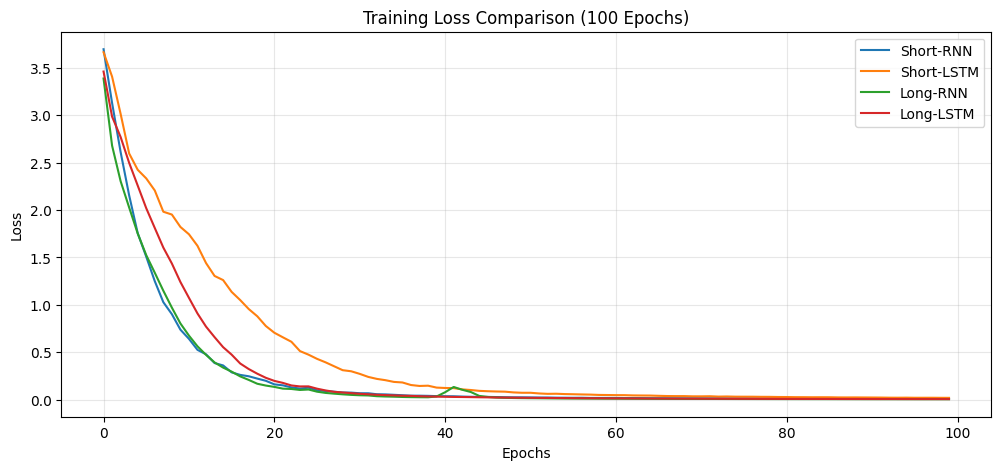


======================================== COMPARISON TABLE ========================================
Dataset Model  Epochs Accuracy                                               Sample Output
  Short   RNN      20   1.0000     Once little girl who lived in a village. in a village. 
  Short  LSTM      20   0.9750     Once little girl who lived in a little girl who lived i
  Short   RNN      50   1.0000     Once girl who lived in a village.girl who lived in a vi
  Short  LSTM      50   1.0000     Once in a village...rl who lived in a village...rl who 
  Short   RNN     100   1.0000     Once girl who lived in a village.girl who lived in a vi
  Short  LSTM     100   1.0000     Once little girl who lived in a village..ho lived in a 
   Long   RNN      20   0.9898  Chen is af intensive study, Chen still maintains a passion
   Long  LSTM      20   1.0000 Chen is intears sting LaTeX reports. \nEven after many hour
   Long   RNN      50   1.0000 Chen is an  and writing LaTeX reports. \nEven afte

In [91]:
#Visualization
plt.figure(figsize=(12, 5))
for label, losses in all_losses.items():
    plt.plot(losses, label=label)
plt.title("Training Loss Comparison (100 Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

df = pd.DataFrame(all_metrics)
print("\n" + "="*40 + " COMPARISON TABLE " + "="*40)
print(df.to_string(index=False))
print("="*98)